# Friedman H-statistic Explainer Demo

This example demonstrates run [Friedman's H-statistic](https://christophm.github.io/interpretable-ml-book/interaction.html#theory-friedmans-h-statistic) explainer using
the H2O Sonar library and retrieve the data and plot with original features interactions.

In [1]:
import os
import logging

import datatable
import daimojo
import webbrowser

from h2o_sonar import interpret
from h2o_sonar.lib.api import commons
from h2o_sonar.lib.api import explainers
from h2o_sonar.explainers import friedman_h_statistic_explainer as explainer
from h2o_sonar.lib.api.models import ModelApi

In [2]:
# explainer description
interpret.describe_explainer(explainer.FriedmanHStatisticExplainer)

{'id': 'h2o_sonar.explainers.friedman_h_statistic_explainer.FriedmanHStatisticExplainer',
 'name': 'FriedmanHStatisticExplainer',
 'display_name': "Friedman's H-statistic",
 'tagline': 'FriedmanHStatisticExplainer.',
 'description': "Friedman's H-statistic describes the amount of variance explained by the feature *pair*. It's expressed with a graph where most important original features are nodes and the interaction scores are edges.\nWhen features interact with each other, then the influence of the features on the prediction does not have be additive, but more complex. For instance the contribution might be greater than the sum of contributions.\nFriedman's H-statistic calculation is computationally intensive and typically requires long time to finish - calculation duration grows with the number of features and bins.",
 'brief_description': 'FriedmanHStatisticExplainer.',
 'model_types': ['iid'],
 'can_explain': ['regression', 'binomial'],
 'explanation_scopes': ['global_scope'],
 'ex

## Interpretation

In [3]:
# dataset
dataset_path = "../../data/predictive/pd_ice_creditcard_10_rows.csv"

# Driverless AI MOJO model
mojo_path = "../../data/predictive/models/creditcard-regression.mojo"
target_col = "LIMIT_BAL"
mojo_model = daimojo.model(mojo_path)
model = ModelApi().create_model(
    model_src=mojo_model,
    target_col=target_col,
    used_features=list(mojo_model.feature_names),
)

# scikit-learn model
# mojo_path = "../../data/predictive/models/creditcard-binomial-sklearn-gbm.pkl"
# target_col = "default payment next month"

# results
results_location = "./results"
os.makedirs(results_location, exist_ok=True)

In [4]:
interpretation = interpret.run_interpretation(
    dataset=dataset_path,
    model=model,
    target_col=target_col,
    results_location=results_location,
    explainers=[explainer.FriedmanHStatisticExplainer.explainer_id()],
    log_level=logging.INFO,
)

/home/user/h/mli/git/h2o-sonar-FLOSS/.venv/lib/python3.11/site-packages/ragas/metrics/__init__.py:1: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain_core.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain_core.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

  from ragas.metrics._answer_correctness import AnswerCorrectness, answer_correctness
/home/user/h/mli/git/h2o-sonar-FLOSS/.venv/lib/python3.11/site-packages/ragas/metrics/__init__.py:4: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain.pydantic_v1 module was a compatibility shim for pydantic 

## Explainer Result

In [5]:
# retrieve the result
result = interpretation.get_explainer_result(
    explainer.FriedmanHStatisticExplainer.explainer_id()
)

In [6]:
# open interpretation HTML report in web browser
webbrowser.open(interpretation.result.get_html_report_location())

True

In [7]:
# summary
result.summary()

{'id': 'h2o_sonar.explainers.friedman_h_statistic_explainer.FriedmanHStatisticExplainer',
 'name': 'FriedmanHStatisticExplainer',
 'display_name': "Friedman's H-statistic",
 'tagline': 'FriedmanHStatisticExplainer.',
 'description': "Friedman's H-statistic describes the amount of variance explained by the feature *pair*. It's expressed with a graph where most important original features are nodes and the interaction scores are edges.\nWhen features interact with each other, then the influence of the features on the prediction does not have be additive, but more complex. For instance the contribution might be greater than the sum of contributions.\nFriedman's H-statistic calculation is computationally intensive and typically requires long time to finish - calculation duration grows with the number of features and bins.",
 'brief_description': 'FriedmanHStatisticExplainer.',
 'model_types': ['iid'],
 'can_explain': ['regression', 'binomial'],
 'explanation_scopes': ['global_scope'],
 'ex

In [8]:
# Parameters
result.params()

{'features_number': 4,
 'grid_resolution': 3,
 'features': None,
 'sample_size': 25000}

### Display Data

In [9]:
result.data()

,feature,interactions
,▪▪▪▪,▪▪▪▪▪▪▪▪
0,'SEX' and 'MARRIAGE',6.16078e-12
1,'SEX' and 'EDUCATION',7.55627e-13
2,'EDUCATION' and 'MARRIAGE',5.37272e-13
3,'EDUCATION' and 'AGE',2.65952e-13
4,'MARRIAGE' and 'AGE',2.57216e-13
5,'SEX' and 'AGE',1.00249e-13


### Plot Feature Interactions Data

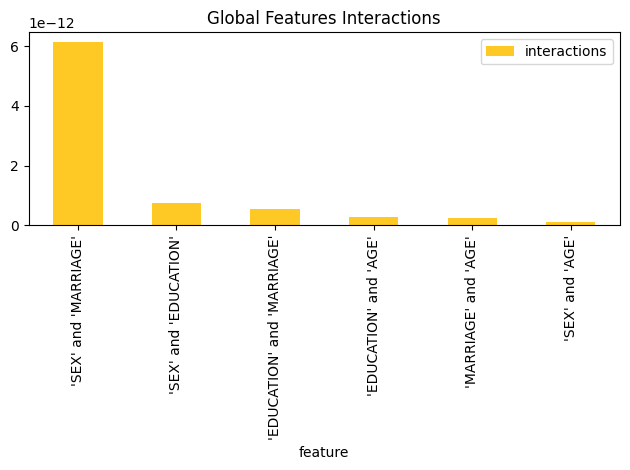

In [10]:
result.plot()

### Save Explainer Log and Data

In [11]:
# save the explainer log
log_file_path = "./feature-interactions-demo.log"
result.log(path=log_file_path)

In [12]:
!cat $log_file_path

2026-01-29 16:02:02,902 WARNING Explainer h2o_sonar.explainers.friedman_h_statistic_explainer.FriedmanHStatisticExplainer is missing the required Python package(s) which must be installed: 'r'
2026-01-29 16:02:02,902 INFO Friedman's H-statistic 7bed1afa-16d6-40e8-a1ca-5a406c9f6b84/5d63e9a6-14ba-42a6-8a77-25e02f8050a9: getting features list, importance and metadata...
2026-01-29 16:02:02,902 INFO Friedman's H-statistic 7bed1afa-16d6-40e8-a1ca-5a406c9f6b84/5d63e9a6-14ba-42a6-8a77-25e02f8050a9 all most important model features: ['SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
2026-01-29 16:02:02,903 INFO Friedman's H-statistic 7bed1afa-16d6-40e8-a1ca-5a406c9f6b84/5d63e9a6-14ba-42a6-8a77-25e02f8050a9: features used by model: ['SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4'

In [13]:
# save the explainer data
result.zip(file_path="./feature-interactions-demo-archive.zip")

In [14]:
!unzip -l feature-interactions-demo-archive.zip

Archive:  feature-interactions-demo-archive.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
     3716  2026-01-29 16:02   explainer_h2o_sonar_explainers_friedman_h_statistic_explainer_FriedmanHStatisticExplainer_5d63e9a6-14ba-42a6-8a77-25e02f8050a9/result_descriptor.json
        2  2026-01-29 16:02   explainer_h2o_sonar_explainers_friedman_h_statistic_explainer_FriedmanHStatisticExplainer_5d63e9a6-14ba-42a6-8a77-25e02f8050a9/problems/problems_and_actions.json
      110  2026-01-29 16:02   explainer_h2o_sonar_explainers_friedman_h_statistic_explainer_FriedmanHStatisticExplainer_5d63e9a6-14ba-42a6-8a77-25e02f8050a9/global_html_fragment/text_html.meta
      399  2026-01-29 16:02   explainer_h2o_sonar_explainers_friedman_h_statistic_explainer_FriedmanHStatisticExplainer_5d63e9a6-14ba-42a6-8a77-25e02f8050a9/global_html_fragment/text_html/explanation.html
    26645  2026-01-29 16:02   explainer_h2o_sonar_explainers_friedman_h_statistic_explainer_FriedmanHStatisticEx